In [1]:
# Load environment variables and set up auto-reload
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

# Remove LangSmith env vars so tracing goes only to Langfuse
from utils import disable_langsmith
disable_langsmith()

# Resolve a CA bundle that works behind the corporate proxy for requests-based clients.
candidate_paths = [
    os.getenv("CORP_CA_BUNDLE"),
    os.getenv("REQUESTS_CA_BUNDLE"),
    os.getenv("SSL_CERT_FILE"),
    "/etc/ssl/certs/ca-certificates.crt",
    "/usr/lib/ssl/cert.pem",
]
selected_bundle = next(
    (path for path in candidate_paths if path and Path(path).exists()),
    None,
 )

if selected_bundle:
    os.environ["REQUESTS_CA_BUNDLE"] = selected_bundle
    os.environ["SSL_CERT_FILE"] = selected_bundle
    os.environ.setdefault("CURL_CA_BUNDLE", selected_bundle)

%load_ext autoreload
%autoreload 2


# Multi-Agent Research System

This notebook combines all the previous components into a single system.

Here is our overall research flow:

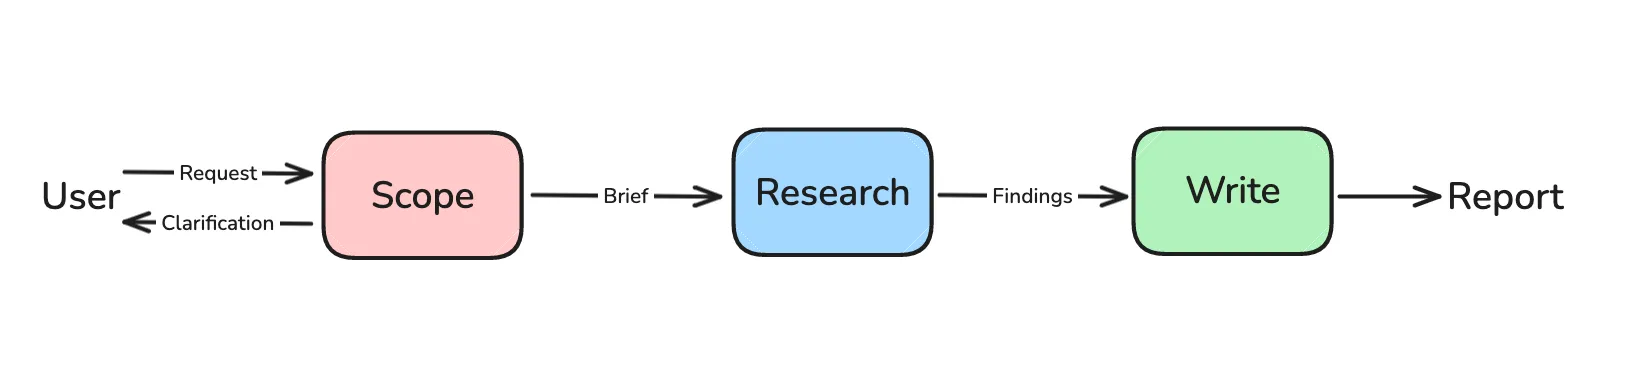

We've built research scoping and multi-agent research in previous notebooks.

Now, we'll add the final report generation step.

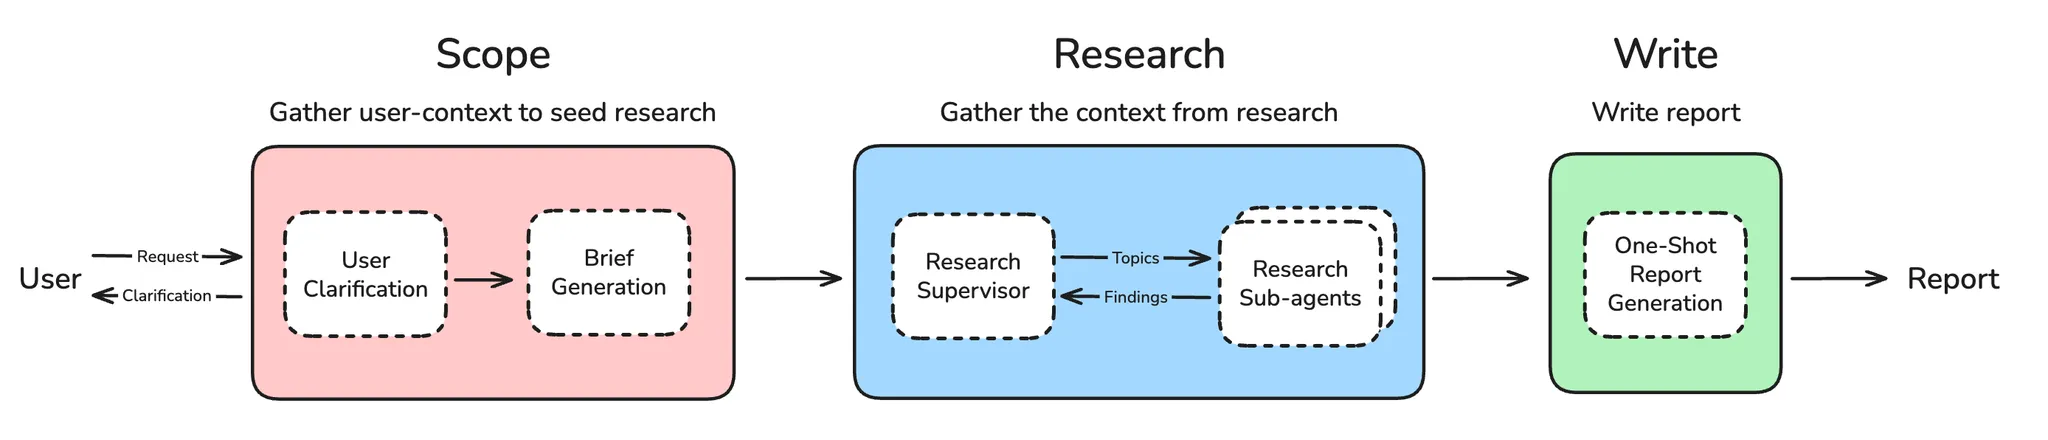

### Agent 

We simply can re-use the components we've already built.

In [2]:
%%writefile ../src/deep_research_from_scratch/research_agent_full.py

"""End-to-end deep research system combining scope, research, and report synthesis.

This module composes the scoping, multi-agent research, and report generation
components into a single LangGraph workflow. The pipeline:
1. Clarifies user intent and generates a research brief
2. Conducts parallel research on multiple sub-topics
3. Synthesizes findings into a comprehensive markdown report

This is the main entry point for the complete deep research system.
"""

import asyncio
import os
import uuid
from pathlib import Path

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent
from deep_research_from_scratch.prompts import final_report_generation_prompt
from deep_research_from_scratch.research_agent_scope import scope_research
from deep_research_from_scratch.state_scope import AgentState
from deep_research_from_scratch.trend_dimensions import (
    format_dimensions_for_prompt,
    load_trend_dimensions,
)
from deep_research_from_scratch.utils import (
    download_images,
    get_today_str,
    normalize_model_id,
)

load_dotenv()


# ===== CONFIGURATION =====

_DEFAULT_WRITER_MODEL = "azure_openai:GPT-54-2026-03-05"


def _build_model(model_id: str, **kwargs):
    """Build an Azure OpenAI model instance from a model identifier string.

    Extracts the deployment name from the model identifier using the
    convention that model name equals deployment name (e.g.,
    "azure_openai:gpt-5.3" -> deployment "GPT-5.3").
    """
    normalized_model_id = normalize_model_id(model_id)
    deployment = normalized_model_id.split(":")[-1]
    return init_chat_model(
        model=normalized_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        **kwargs,
    )


# ===== REPORT GENERATION =====

def _build_report_dimensions_section() -> str:
    """Build the expert dimensions section for the final report prompt.

    Returns a full XML section string when dimensions are available,
    or an empty string for graceful degradation (no empty XML block).
    """
    dims = format_dimensions_for_prompt(load_trend_dimensions())
    if not dims:
        return ""
    return (
        "<Expert Dimensions>\n"
        "Use these expert analytical dimensions where relevant to structure the final report, "
        "organize findings, and identify gaps or future opportunities:\n"
        f"{dims}\n"
        "Apply them selectively based on the research topic rather than forcing every dimension.\n"
        "</Expert Dimensions>\n"
    )


async def final_report_generation(
    state: AgentState,
    config: RunnableConfig,
):
    """Generate the final comprehensive report from research findings.

    Downloads collected images to local storage first, then synthesizes
    research notes into a well-structured markdown report with embedded
    image references.

    Model is controlled by config["configurable"]["writer_model"]
    (default: "azure_openai:GPT-54-2026-03-05").
    Backward compatibility: also accepts "final_report_model".

    Args:
        state: Output from supervisor phase containing notes, research brief,
            and accumulated images.
        config: LangGraph runtime config; supports configurable["writer_model"]
            (or legacy configurable["final_report_model"]) and
            configurable["thread_id"] for output directory naming.

    Returns:
        Dictionary containing the final markdown report and downloaded images.
    """
    configurable = config.get("configurable", {})
    writer_model = _build_model(
        configurable.get(
            "writer_model",
            configurable.get("final_report_model", _DEFAULT_WRITER_MODEL),
        ),
        temperature=0,
    )

    notes = state.get("notes", [])
    rq = state.get("research_brief")
    research_brief = rq.research_brief if hasattr(rq, "research_brief") else (rq or "")
    images = state.get("images", [])

    # Download images BEFORE report generation so local paths are available
    thread_id = configurable.get("thread_id", "") or str(uuid.uuid4())
    # Anchor to project root so the path is correct regardless of
    # the working directory (e.g. when running from notebooks/).
    _project_root = Path(__file__).resolve().parent.parent.parent
    output_dir = _project_root / "reports" / thread_id / "images"

    if images:
        downloaded_images = await asyncio.to_thread(download_images, images, output_dir)
    else:
        downloaded_images = []

    # Format image metadata for the report prompt
    if downloaded_images:
        lines = []
        for i, img in enumerate(downloaded_images, 1):
            # Use relative path so the report is portable regardless of where it is opened
            path = ("images/" + Path(img.local_path).name) if img.local_path else img.url
            line = f"[{i}] {img.title or img.url}"
            if img.description:
                line += f"\n    Description: {img.description}"
            if img.source_page:
                line += f"\n    Source: {img.source_page}"
            line += f"\n    Path: {path}"
            lines.append(line)
        images_text = "\n".join(lines)
    else:
        images_text = "No images were found during research."

    findings_text = "\n\n".join(notes) if isinstance(notes, list) else str(notes)

    system_prompt = final_report_generation_prompt.format(
        research_brief=research_brief,
        date=get_today_str(),
        findings=findings_text,
        images=images_text,
    )

    # Append expert dimensions as supplementary guidance in the user turn
    dims = _build_report_dimensions_section()
    user_content = "Generate the comprehensive research report now."
    if dims:
        user_content = f"{dims}\n\n{user_content}"

    result = await writer_model.ainvoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content),
    ])

    return {
        "final_report": result.content,
        "images": downloaded_images or images,
    }


# ===== GRAPH CONSTRUCTION =====

deep_researcher_builder = StateGraph(AgentState)

deep_researcher_builder.add_node("scope_research", scope_research)
deep_researcher_builder.add_node("supervisor_agent", supervisor_agent)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

deep_researcher_builder.add_edge(START, "scope_research")
deep_researcher_builder.add_edge("scope_research", "supervisor_agent")
deep_researcher_builder.add_edge("supervisor_agent", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

agent = deep_researcher_builder.compile()


Overwriting ../src/deep_research_from_scratch/research_agent_full.py


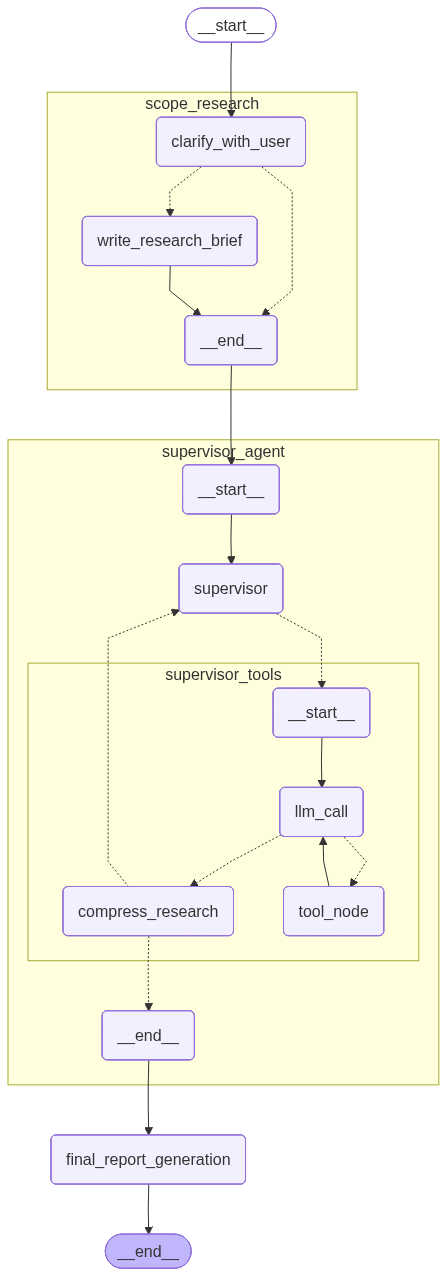

In [3]:
# Run the workflow
import base64
import httpx
from utils import format_messages
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
mermaid = full_agent.get_graph(xray=True).draw_mermaid()
encoded = base64.urlsafe_b64encode(mermaid.encode("utf-8")).decode("ascii")
image_url = f"https://mermaid.ink/img/{encoded}?type=png&bgColor=%21white"

with httpx.Client(timeout=20.0, verify=False, trust_env=True) as client:
    response = client.get(image_url)
    response.raise_for_status()
    png_bytes = response.content

display(Image(png_bytes))

LangGraph has a default recursion limit of 25 steps to prevent infinite loops. For complex research workflows that require iterative rounds of research, this limit needs to be increased. As explained in [LangGraph's troubleshooting guide](https://langchain-ai.github.io/langgraph/troubleshooting/errors/GRAPH_RECURSION_LIMIT/), the recursion limit counts every node execution in the graph. In our multi-agent research system:

- **Single Research Agent**: May take 8-12 steps for tool calls and compression
- **Multi-Agent Supervisor**: Each sub-agent spawned adds additional steps
- **Iterative Research**: Supervisor may conduct multiple rounds of research to fill gaps
- **Full Workflow**: Includes scoping, research brief generation, supervision, and report generation

We set the recursion limit to **50** to accommodate:
- Complex research topics requiring multiple research rounds
- Parallel sub-agent execution
- Deep research with many tool calls
- Complete workflow execution from scoping to final report

This allows the supervisor to conduct iterative rounds of research when initial findings have gaps, ensuring comprehensive coverage of complex research topics.

In [ ]:
from langchain_core.messages import HumanMessage
from utils import init_langfuse_tracing
import uuid

langfuse_handler = init_langfuse_tracing()

thread = {"configurable": {"thread_id": str(uuid.uuid4()), "recursion_limit": "50", 
         "scope_model":         "azure_openai:GPT-55-2026-04-24",
         "research_model":      "azure_openai:GPT-55-2026-04-24",
         "summarization_model": "azure_openai:GPT-55-2026-04-24",
         "compress_model":      "azure_openai:GPT-55-2026-04-24",
         "supervisor_model":    "azure_openai:GPT-55-2026-04-24",
         "writer_model":        "azure_openai:GPT-55-2026-04-24",
        },
         "callbacks": [langfuse_handler],
         "metadata": {
             "notebook": "5_full_agent",
             "langfuse_session_id": "20260506",
         },
}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="近半年来中日韩高端身体护理的液体设计元素的趋势，包括颜色、装饰和纹理感，不要考虑包装的设计。请给出参考的图片")]}, config=thread)

if "messages" in result:
    format_messages(result["messages"])
else:
    print(f"Result keys: {list(result.keys())}")
    print("No messages key found; previewing final_report:")
    print((result.get("final_report") or "")[:800])


In [ ]:
# result = await full_agent.ainvoke({"messages": [HumanMessage(content="juice design element是指精华液本身的内容物外观; premium指高端奢华")]}, config=thread)

In [ ]:
if "messages" in result:
    format_messages(result["messages"])
elif "supervisor_messages" in result:
    format_messages(result["supervisor_messages"])
else:
    print(f"Result keys: {list(result.keys())}")

In [ ]:
from pathlib import Path
from IPython.display import Markdown, display

report = result.get("final_report")
if not report:
    print("No final_report in result yet. Current keys:", list(result.keys()))
else:
    display(Markdown(report))

    output_path = Path(f"../reports/{thread['thread_id']}/report.md")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(report, encoding="utf-8")

    print(f"Saved to: {output_path.resolve()}")

### Evaluation

Now let's evaluate the full end-to-end research system. We test whether the final reports:

1. Have proper structure (markdown sections, title, sources)
2. Cite diverse, relevant sources
3. Make claims consistent with cited material
4. Comprehensively address the research question

We use a combination of **heuristic gates** (structure) and **LLM-as-judge** evaluators (source coverage, factual consistency, completeness).

> **Note**: E2E evals always run and are **not** hidden behind a slow marker or skip flag. Each example invokes the full research pipeline with live web search.

> **Judge model limitation**: The judge model (`GPT-54-2026-03-05`) may be from the same model family as the generation model. LLM-judge scores are therefore **advisory** and should be spot-checked when scores shift materially.

In [21]:
# E2E evaluation dataset examples
# Each example has a plain-text query and expected report characteristics.
# The target function wraps the query into HumanMessage for the agent.

e2e_examples = [
    # Example 1 — Overview / survey query
    {
        "inputs": {"query": "What is Retrieval Augmented Generation (RAG)? Explain its core architecture, common chunking strategies, and when to use RAG versus fine-tuning."},
        "outputs": {
            "expected_sources": ["arxiv.org", "huggingface.co", "langchain.com", "llamaindex.ai"],
            "expected_facts": [
                "RAG retrieves external documents and feeds them to a language model at inference time",
                "Vector databases are used to store and retrieve document embeddings",
                "Chunking strategy affects retrieval quality — common approaches include fixed-size, sentence-level, and semantic chunking",
                "Fine-tuning changes model weights while RAG keeps the model frozen and augments with external knowledge",
            ],
            "expected_sections": ["introduction", "architecture", "chunking", "sources"],
        },
    },
    # Example 2 — Head-to-head comparison
    {
        "inputs": {"query": "Compare the pricing, deployment features, and developer experience of Vercel versus Netlify for deploying Next.js applications."},
        "outputs": {
            "expected_sources": ["vercel.com", "netlify.com"],
            "expected_facts": [
                "Vercel is the creator and primary maintainer of Next.js",
                "Vercel offers serverless and edge functions natively",
                "Netlify supports Next.js through an adapter or plugin",
            ],
            "expected_sections": ["introduction", "pricing", "features", "developer experience", "sources"],
        },
    },
    # Example 3 — Multi-sub-question query
    {
        "inputs": {"query": "What are WebSockets? How do they differ from HTTP long-polling and Server-Sent Events? When should each be used in production web applications?"},
        "outputs": {
            "expected_sources": ["developer.mozilla.org", "ietf.org"],
            "expected_facts": [
                "WebSockets provide full-duplex bidirectional communication over a single TCP connection",
                "Server-Sent Events (SSE) are unidirectional from server to client",
                "HTTP long-polling holds the connection open until the server has data to send",
                "WebSockets use the ws:// or wss:// protocol scheme",
            ],
            "expected_sections": ["introduction", "comparison", "use cases", "sources"],
        },
    },
]

print(f"Defined {len(e2e_examples)} E2E evaluation examples.")

Defined 3 E2E evaluation examples.


In [12]:
from utils import init_langfuse

langfuse = init_langfuse()

dataset_name = "deep_research_e2e"

try:
    ds = langfuse.get_dataset(dataset_name)
    print(f'Dataset "{dataset_name}" already exists ({len(ds.items)} items).')
except Exception:
    ds = None

if ds is None or len(ds.items) == 0:
    if ds is None:
        langfuse.create_dataset(
            name=dataset_name,
            description=(
                "End-to-end evaluation of the full multi-agent research system. "
                "Each example tests report structure, source coverage, factual consistency, and completeness."
            ),
        )
    for example in e2e_examples:
        langfuse.create_dataset_item(
            dataset_name=dataset_name,
            input=example["inputs"],
            expected_output=example["outputs"],
        )
    langfuse.flush()
    print(f'Created dataset "{dataset_name}" with {len(e2e_examples)} items.')

Dataset "deep_research_e2e" already exists.


#### Evaluators

We define four evaluators:

| Evaluator | Type | Gate? | What it checks |
| --- | --- | --- | --- |
| `evaluate_report_structure` | Heuristic | **Must pass** | Report has a title, ≥2 section headers, and a Sources section |
| `evaluate_report_source_coverage` | LLM judge | Advisory | Sources are diverse, relevant, and ground claims |
| `evaluate_report_factual_consistency` | LLM judge | Advisory | Claims are consistent with cited material |
| `evaluate_report_completeness` | LLM judge | Advisory | All material aspects of the question are addressed |

In [22]:
import re
from langchain_core.messages import HumanMessage
from langfuse import Evaluation
from deep_research_from_scratch.prompts import (
    REPORT_SOURCE_COVERAGE_PROMPT,
    REPORT_FACTUAL_CONSISTENCY_PROMPT,
    REPORT_COMPLETENESS_PROMPT,
)
from utils import JudgeResult, init_judge_model, to_langfuse_evaluation


# ---------- Heuristic evaluator ----------

def evaluate_report_structure(*, input, output, expected_output, metadata=None, **kwargs):
    """Heuristic gate: verify report has basic markdown structure."""
    report = output.get("final_report", "")
    if not report:
        return Evaluation(name="report_structure", value=0.0, comment="No report produced.")

    headings = re.findall(r"^#{1,3}\s+.+", report, re.MULTILINE)
    section_headers = re.findall(r"^#{2,3}\s+.+", report, re.MULTILINE)
    has_sources = bool(re.search(
        r"^#{1,3}\s+(Sources|References|Bibliography)",
        report, re.MULTILINE | re.IGNORECASE,
    ))
    all_pass = len(headings) >= 1 and len(section_headers) >= 2 and has_sources
    return Evaluation(
        name="report_structure",
        value=1.0 if all_pass else 0.0,
        comment=f"title={len(headings)>=1}, sections={len(section_headers)}, sources_section={has_sources}",
    )


# ---------- LLM-as-judge evaluators ----------

def _extract_query(input: dict) -> str:
    return input.get("query", "")


def evaluate_report_source_coverage(*, input, output, expected_output, metadata=None, **kwargs):
    """LLM judge: evaluate source diversity and citation grounding."""
    report = output.get("final_report", "")
    if not report:
        return Evaluation(name="report_source_coverage", value=0.0, comment="No report produced.")
    try:
        model = init_judge_model()
        judge = model.with_structured_output(JudgeResult)
        result = judge.invoke([HumanMessage(content=REPORT_SOURCE_COVERAGE_PROMPT.format(
            research_question=_extract_query(input),
            report=report,
            expected_sources=", ".join(expected_output.get("expected_sources", [])),
        ))])
        return to_langfuse_evaluation(
            "report_source_coverage", result,
            prompt_name="REPORT_SOURCE_COVERAGE_PROMPT",
            judge_model="azure_openai:GPT-54-2026-03-05",
        )
    except Exception as e:
        return Evaluation(name="report_source_coverage", value=0.0, comment=f"Evaluator error: {type(e).__name__}: {e}")


def evaluate_report_factual_consistency(*, input, output, expected_output, metadata=None, **kwargs):
    """LLM judge: evaluate whether claims are consistent with cited sources."""
    report = output.get("final_report", "")
    if not report:
        return Evaluation(name="report_factual_consistency", value=0.0, comment="No report produced.")
    try:
        model = init_judge_model()
        judge = model.with_structured_output(JudgeResult)
        result = judge.invoke([HumanMessage(content=REPORT_FACTUAL_CONSISTENCY_PROMPT.format(
            research_question=_extract_query(input),
            report=report,
            expected_facts="\n".join(f"- {f}" for f in expected_output.get("expected_facts", [])),
        ))])
        return to_langfuse_evaluation(
            "report_factual_consistency", result,
            prompt_name="REPORT_FACTUAL_CONSISTENCY_PROMPT",
            judge_model="azure_openai:GPT-54-2026-03-05",
        )
    except Exception as e:
        return Evaluation(name="report_factual_consistency", value=0.0, comment=f"Evaluator error: {type(e).__name__}: {e}")


def evaluate_report_completeness(*, input, output, expected_output, metadata=None, **kwargs):
    """LLM judge: evaluate whether the report addresses all aspects of the question."""
    report = output.get("final_report", "")
    if not report:
        return Evaluation(name="report_completeness", value=0.0, comment="No report produced.")
    try:
        model = init_judge_model()
        judge = model.with_structured_output(JudgeResult)
        result = judge.invoke([HumanMessage(content=REPORT_COMPLETENESS_PROMPT.format(
            research_question=_extract_query(input),
            report=report,
            expected_sections=", ".join(expected_output.get("expected_sections", [])),
        ))])
        return to_langfuse_evaluation(
            "report_completeness", result,
            prompt_name="REPORT_COMPLETENESS_PROMPT",
            judge_model="azure_openai:GPT-54-2026-03-05",
        )
    except Exception as e:
        return Evaluation(name="report_completeness", value=0.0, comment=f"Evaluator error: {type(e).__name__}: {e}")

In [ ]:
import uuid
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

# Build a dedicated graph for evaluation
eval_agent = deep_researcher_builder.compile(checkpointer=InMemorySaver())


async def target_func(*, item, **kwargs):
    """Run the full research pipeline for a single evaluation example."""
    config = {
        "recursion_limit": 50,
        "configurable": {
            "thread_id": str(uuid.uuid4()),
            "scope_model": "azure_openai:GPT-54-2026-03-05",
            "research_model": "azure_openai:GPT-54-2026-03-05",
            "summarization_model": "azure_openai:GPT-54-2026-03-05",
            "compress_model": "azure_openai:GPT-54-2026-03-05",
            "supervisor_model": "azure_openai:GPT-54-2026-03-05",
            "writer_model": "azure_openai:GPT-54-2026-03-05",
        },
    }
    return await eval_agent.ainvoke(
        {"messages": [HumanMessage(content=item.input["query"])]},
        config=config,
    )


experiment = langfuse.run_experiment(
    name=dataset_name,
    run_name=f"Deep Research E2E — {uuid.uuid4().hex[:8]}",
    data=langfuse.get_dataset(dataset_name).items,
    task=target_func,
    evaluators=[
        evaluate_report_structure,
        evaluate_report_source_coverage,
        evaluate_report_factual_consistency,
        evaluate_report_completeness,
    ],
)
print(f"Experiment complete: {len(experiment.item_results)} items evaluated")
experiment.format()

You can click the above link to review the E2E experiment results in Langfuse.

**Interpreting results:**

| Evaluator | Interpretation |
| --- | --- |
| `report_structure` | **Must pass** on every example. Failures indicate missing markdown structure. |
| `report_source_coverage` | Advisory — score 0.75+ indicates good source diversity. |
| `report_factual_consistency` | Advisory — evaluates citation-grounded plausibility, not external fact-checking. |
| `report_completeness` | Advisory — score 0.75+ indicates comprehensive coverage of the research question. |

When reviewing:
- Inspect **score distributions**, not just averages
- Check **low-confidence** judge outputs — they may need human spot-checking
- Look for systematic patterns (e.g., one criterion consistently low across examples)